In [2]:
import pandas as pd

# Summary Functions and Maps

## Sumamry Functions

We went over these in the first `course.ipynb` notebook, which covers the `describe()` method. One thing we didn't note is that when using `describe()` on your data pandas automatically takes into consideration the data type so for numeric values it returns `count, mean, max etc` while for string values it returns `count, frequency, unique, top`. 

On top that we can get the mean value of any column using the `mean()` method. We can do the same with `median()` to compute the median value.

We can get a list of unique values using `unique()` method and if we want to see each value how many times it appeared we can use `value_counts()` for that.

In [ ]:
df = pd.read_csv('dataIn/world_gdp_data.csv', encoding="latin1")

# print(df.describe())
print("--- Mean ---")
print(df["1980"].mean())
print("--- Unique ---")
print(df["1980"].unique())
print(df["2015"].value_counts())

--- Mean ---
3.1134751773049647
--- Unique ---
[  nan   2.7  -5.4   2.4   8.2   0.7   2.9   2.3   7.1   7.5   4.4   5.
   9.3   0.6  12.    9.2   5.7   4.   -6.8   5.3   9.9   2.2  -3.   -6.
   7.9   7.4  12.7   0.8   5.9   5.2  -0.5  13.4   8.    4.9   3.4  -8.6
   4.8  -3.8  -1.7   1.8   0.    1.3   0.5  15.1   3.7   2.6  -2.1   7.3
  10.3   0.2 -21.6   3.6   3.1  -4.    3.2  11.1   5.6   0.1  -1.6  10.
   1.5  -0.8   0.4  18.8   3.3   7.  -10.1   9.5   6.4   3.8   4.2  -2.3
   1.    4.6   4.5   6.1   6.9  11.7   7.7   5.1   6.7  -1.   -3.6  -6.1
  -0.6  10.1  -2.7   6.6   1.2   5.8   2.5  -6.5  10.5  -1.1  15.8  10.4
  -3.4  -1.8  -2.2  -0.3   6.    5.5  -4.9  -3.5   3.9]
<bound method IndexOpsMixin.value_counts of 0       1.0
1       2.2
2       3.7
3       1.4
4       0.9
       ... 
191     7.0
192     3.7
193   -28.0
194     2.9
195     1.8
Name: 2015, Length: 196, dtype: float64>


# map() & apply()

`map()` is a method we can use on a `Series` to transform its values. For example if we wanted to center the values around the mean we could do so by computing the mean and then subtracting the mean from each value on the column. We can see in the example below that the returned value of `map()` is a Series so that should be a thing to look out for. 

`apply()` does the exact same thing as map but it lets us define more verbose functions and can be applied to either rows or columns. You can also pass more parameters to the apply function using the `args` parameters. With the `axis` parameter you can say if you want the operation to be applied to each row or each column.

> `map()` and `apply()` do not modify the original series they return a new one so you must use the assignment operator `=` to modify the original one.

For the mean centering above we can also do a much easier `vectorized operation` by simpli subtracting DataFrames from one another so `df["1980"] = df["1980].mean()` and it will work just fine while also being faster.

In [ ]:
# -- Mean centered values
print(df["1980"].map(lambda row : row - df["1980"].mean()))

# -- apply() example for centered values

def mean_center(row, column_name):
    return row[column_name] - df[column_name].mean()

df.apply(mean_center, axis="columns", args=("1980",)) # without comma it will be treated as a string
print(df["1980"])

# -- Interesting way to use map to find the count of a value in a row

# n_trop = reviews.description.map(lambda desc: "tropical" in desc).sum()
# n_fruity = reviews.description.map(lambda desc: "fruity" in desc).sum()
# descriptor_counts = pd.Series([n_trop, n_fruity], index=['tropical', 'fruity'])

0           NaN
1     -0.413475
2     -8.513475
3           NaN
4     -0.713475
         ...   
191   -6.613475
192         NaN
193         NaN
194    0.786525
195         NaN
Name: 1980, Length: 196, dtype: float64
0      NaN
1      2.7
2     -5.4
3      NaN
4      2.4
      ... 
191   -3.5
192    NaN
193    NaN
194    3.9
195    NaN
Name: 1980, Length: 196, dtype: float64


## Mixing columns

You can mix data from multiple columns using concatenation just like you would with string, so if we wanted intervals for 1980 and 1981 we could do `df["country_names"] + '-' + df["indicator_name"]`. 

> Note that it does not work if the column contains numerical value

In [26]:
print(df["country_name"] + '-' + df["indicator_name"])

0         Afghanistan-Annual GDP growth (percent change)
1             Albania-Annual GDP growth (percent change)
2             Algeria-Annual GDP growth (percent change)
3             Andorra-Annual GDP growth (percent change)
4              Angola-Annual GDP growth (percent change)
                             ...                        
191           Vietnam-Annual GDP growth (percent change)
192    West Bank and Gaza-Annual GDP growth (percent ...
193             Yemen-Annual GDP growth (percent change)
194            Zambia-Annual GDP growth (percent change)
195          Zimbabwe-Annual GDP growth (percent change)
Length: 196, dtype: str


## idxmax() 

It is a function that works on a row and returns the `index` of the maximum value on that row.

In [28]:
idx = df["1980"].idxmax()
print(df.loc[idx, "country_name"]) # highest gdp growth in 1980

Maldives


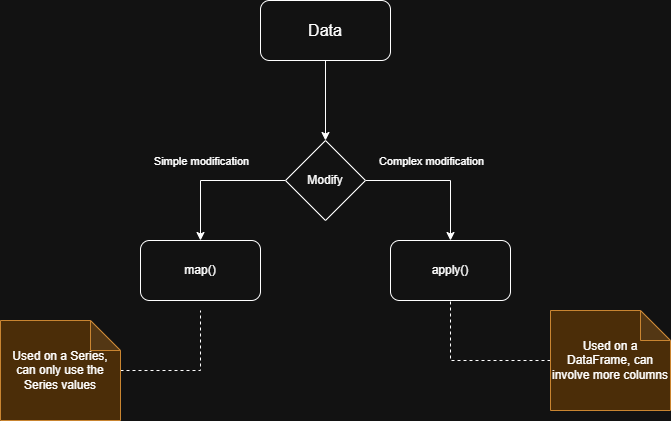